[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duoan/TorchCode/blob/master/templates/13_gpt2_block.ipynb)

# 🔴 Hard: GPT-2 Transformer Block

Implement a full **GPT-2 style Transformer block** — combining everything you've learned.

### Architecture (Pre-Norm)
```
x = x + causal_self_attention(ln1(x))
x = x + mlp(ln2(x))
```

### Signature
```python
class GPT2Block(nn.Module):
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, x: torch.Tensor) -> torch.Tensor: ...
```

### Requirements
- Inherit from `nn.Module`
- `self.ln1`, `self.ln2`: `nn.LayerNorm(d_model)`
- `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`: `nn.Linear` for attention
- `self.mlp`: `nn.Sequential(Linear(d, 4d), GELU(), Linear(4d, d))`
- Attention must be **causal** (mask future positions)
- Pre-norm architecture (LayerNorm *before* attention and MLP)
- Residual connections around both attention and MLP

### GPT-2 Block (Pre-LayerNorm)

GPT-2 uses Pre-Layer Normalization (Pre-LN), unlike the original Transformer block, which uses Post-Layer Normalization (Post-LN). In Pre-LN, each sublayer receives a normalized input, which can be viewed as moving the final LayerNorm in a Post-LN block from after the FFN residual addition to the front, before the MHA.

$$
x_1 = x + \mathrm{Attention}(\mathrm{LN}_1(x))
$$

$$
x_2 = x_1 + \mathrm{MLP}(\mathrm{LN}_2(x_1))
$$

The block returns:

$$
\mathrm{output} = x_2
$$

<style>
.side-by-side img {
    max-width: 300px;
}
.side-by-side td {
    vertical-align: top;
    padding: 10px 20px;
}
</style>

<table class="side-by-side" align="center">
<tr>
<td align="center">

**Pre-LN:** LN → MHA → Add → LN → FFN → Add

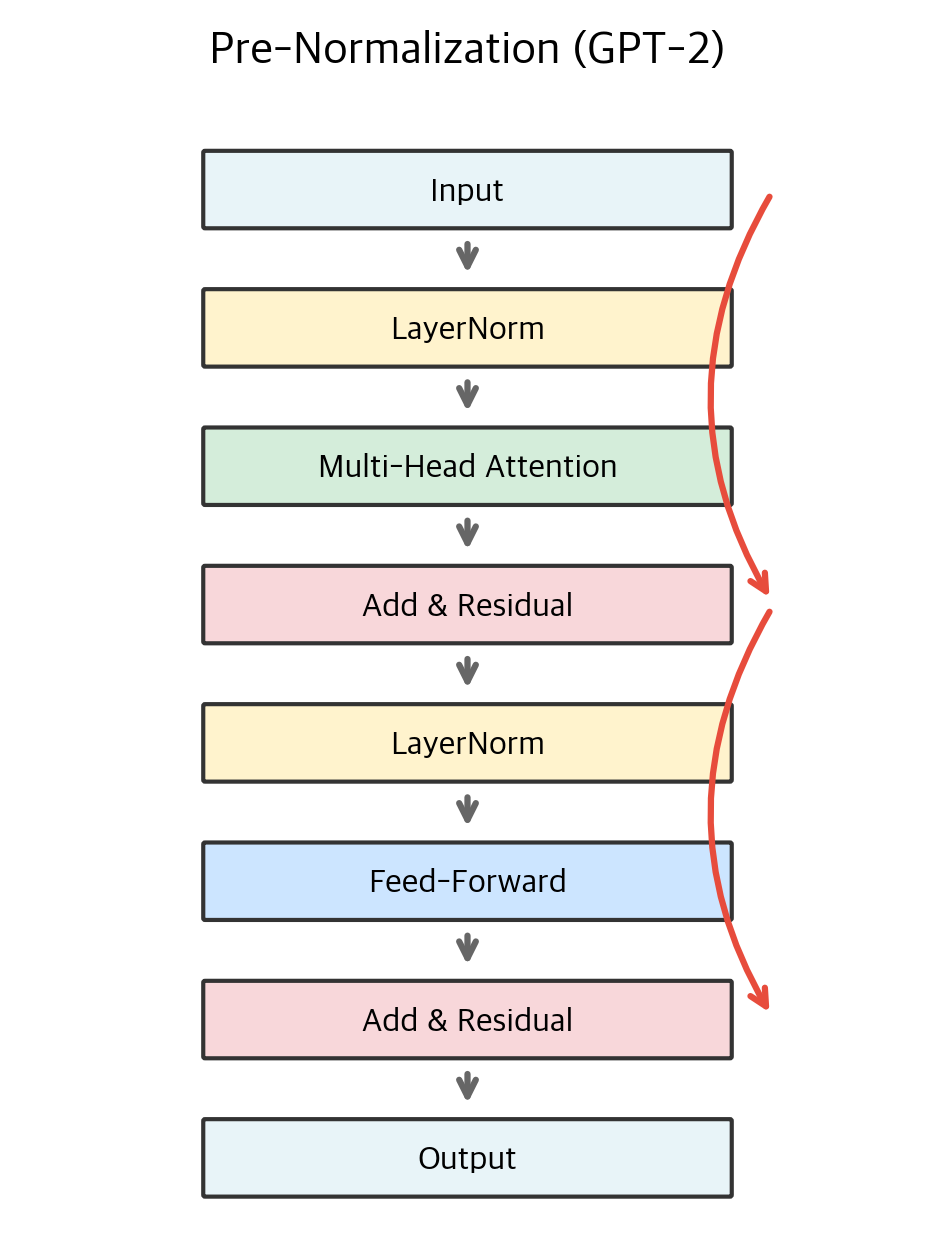

</td>
<td align="center">

**Post-LN:** MHA → Add → LN → FFN → Add → LN

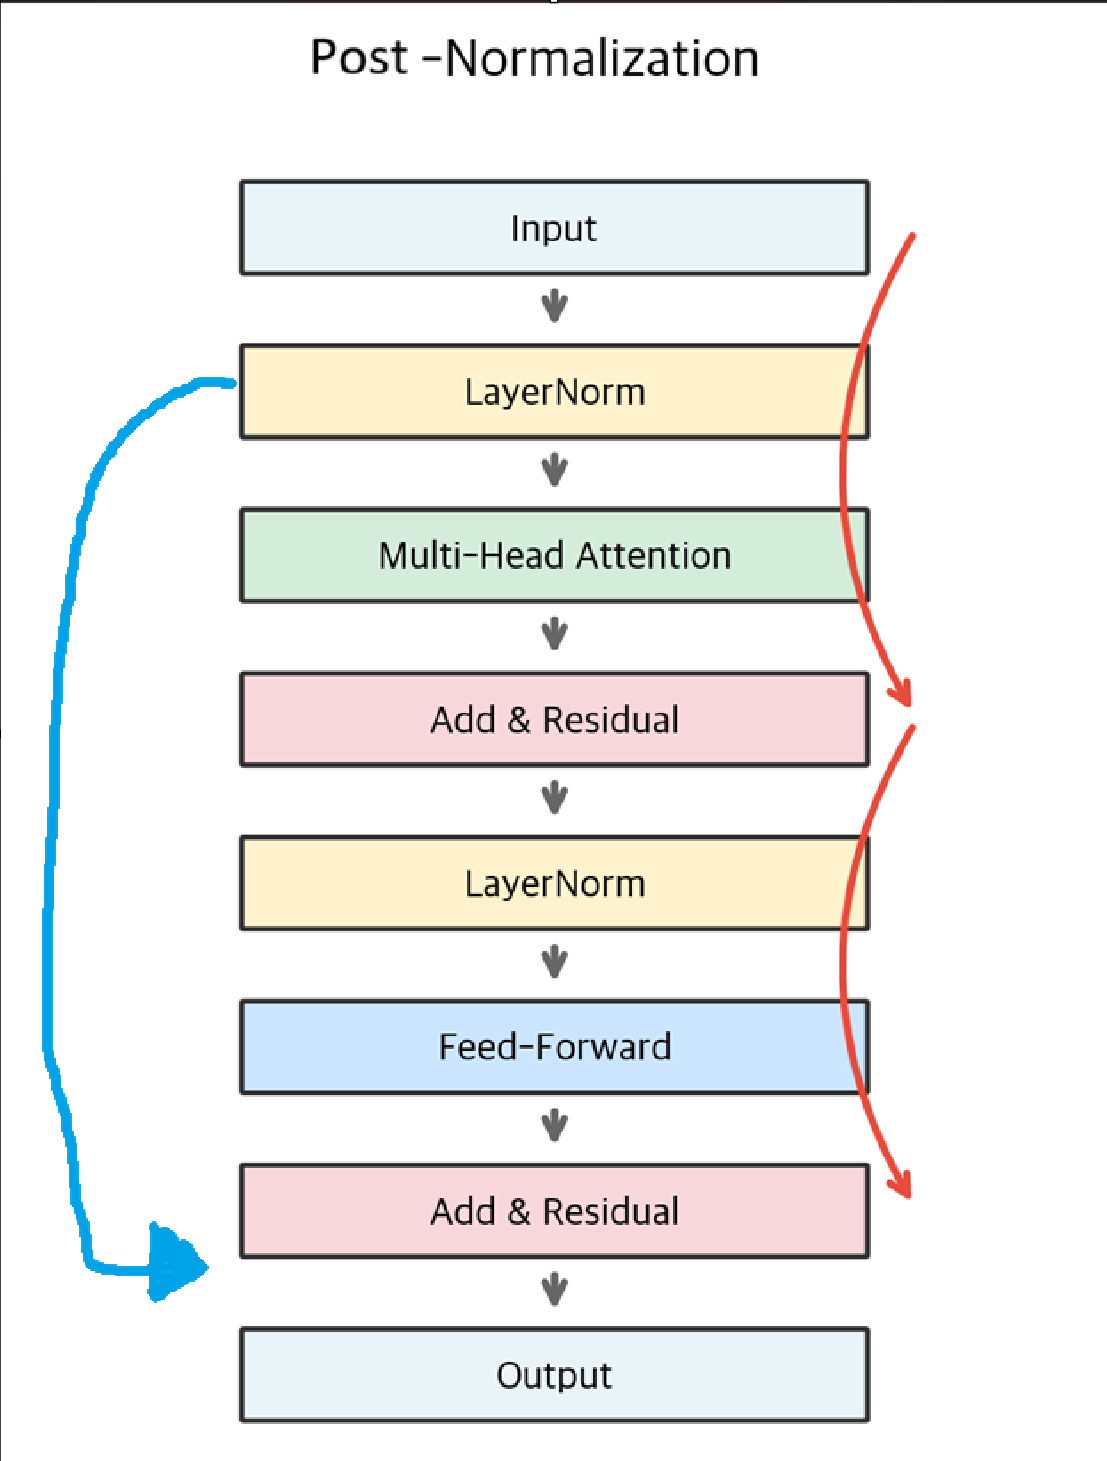

</td>
</tr>
</table>

### My notes:

Where is positional embedding?
- A standard Transformer block does NOT include positional embedding. Instead, the input tokens are first combined with positional embeddings outside the block, and the resulting sum is then fed into the first Transformer block.

In [1]:
# Install torch-judge in Colab (no-op in JupyterLab/Docker)
try:
    import google.colab
    get_ipython().run_line_magic('pip', 'install -q torch-judge')
except ImportError:
    pass


In [2]:
import torch
import torch.nn as nn
import math

In [29]:
# ✏️ YOUR IMPLEMENTATION HERE

class GPT2Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        # pass  # Initialize layers
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), # up projection
            nn.GELU(),
            nn.Linear(4 * d_model, d_model) # down projection
        )
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        

    def forward(self, x):
        # pass  # Pre-norm + causal attention + MLP with residuals
        
        # LN before attention for gpt2blcok
        Q = self.W_q(self.ln1(x))
        K = self.W_k(self.ln1(x))
        V = self.W_v(self.ln1(x))
        
    
        batch_size, seq_len = Q.size(0), Q.size(1)
        
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, dtype=torch.bool, device=Q.device),
            diagonal=1,
        ) # -inf mask

        Q_split = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        K_split = K.view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        V_split = V.view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)



        qk = (Q_split @ K_split.transpose(-2, -1) / math.sqrt(self.head_dim)).masked_fill(causal_mask, float('-inf'))
        multi_head_attn = torch.softmax(qk, dim=-1) @ V_split

        
        attn = multi_head_attn.permute(0, 2, 1, 3).contiguous().view(batch_size, seq_len, self.d_model) # concatenate the heads
        attn = self.W_o(attn)
        
        # Residual -> LN -> MLP -> Residual
        x = x + attn
        output = x + self.mlp(self.ln2(x)) 
        
        return output
        

In [30]:
# 🧪 Debug
torch.manual_seed(0)
block = GPT2Block(d_model=64, num_heads=4)
x = torch.randn(2, 8, 64)
out = block(x)
print("Output shape:", out.shape)           # (2, 8, 64)
print("Is nn.Module?", isinstance(block, nn.Module))
print("Params:", sum(p.numel() for p in block.parameters()))

Output shape: torch.Size([2, 8, 64])
Is nn.Module? True
Params: 49984


In [31]:
from torch_judge import check
check('gpt2_block')


🧪 Testing: GPT-2 Transformer Block (Hard)
──────────────────────────────────────────────────
  ✅ [1/5] Output shape (2.1ms)
  ✅ [2/5] Has LayerNorm (pre-norm architecture) (0.3ms)
  ✅ [3/5] MLP has 4x expansion with GELU (0.3ms)
  ✅ [4/5] Causal masking — future doesn't affect past (1.1ms)
  ✅ [5/5] Gradient flow to all parameters (1.4ms)
──────────────────────────────────────────────────
  🎉 All 5 tests passed! (5.4ms total)
  Progress saved. Run status() to see your dashboard.

